CNN IN KERAS SU MNIST: DALLA TEORICA ALLA VISIONE PRATICA

Preparazione del Volume di Input
Adattare le immagini MNIST per la convoluzione 2D

Come prepariamo un'immagine per essere vista davvero.
Con l'approccio classico per fare digerire MNIS in una rete densa ANN, si utilizza un layer Flatten all'inizio, che però va a distruggere la forma dell'immagine (insieme di vettori piatti)
Per le CNN, dobbiamo preservare la topologia spaziale, mantentendo la struttura a griglia dei pixel.
Il requisito fondamentale di Keras per i layer convoluzionali è la presenza esplicita dei canali colore, anche per immagini in scale di grigio, trasformando le matrici in volumi tensoriali.
Cosa significa tecnicamente aggiungere questa profondità?

La Quarta Dimensione
Dimensionamento dei tensori per la Computer Vision
I dati MNIST originali sono caricati come un array di forma 60000x 28x28, privo dell'informazione sul canale colore. Keras è esigente, vuole un tensore a 4 dimensioni (batch, altezza, larghezza e canali). Doppiamo aggiungere il canale unitario finale con l'operazione di reshape, portanto la forma a 28x28x1, per indicare un singolo canale. Senza questa trasformazione, il kernel della CNN non avrebbe una base su cui scorrere.
Questa formattazione permette al kernel di scorrere correttamente lungo altezza e larghezza interpretando il tensore come un volume spaziale.
La trasformazione assicura che il numero di campioni, le dimensioni spaziale e i canali siano definiti esplicitamente
Una volta sistemata la forma, dobbiamo occuparci della sostanza dei pixel

Preprocessing per CNN
Normalizzazione dei Pixel
I computer leggono i pixel con valori tra 0 e 255, ma le reti neurali preferiscono numeri piccoli, per cui vengono scalati nell'intervallo 0,1 dividendo per 255, accelerando la convergenza dell'ottimizzatore. Questo permette a Adam di naviare tra valori meno ripidi e più stabili.
Label Encoding
Allo stesso tempo prepariamo le etichette. Si utilizzano etichette intere con 'sparse_categorical_crossEntropy' o si convertono in vettore one-hot per la cross-entropy standard.
Data Splitting
Sebbene MNIST sia pre-diviso, è buona norma riservare una porzione del set di addestramento per la validazoine durante le epoche.

Integrità Spaziale
Perchè non usare 'Flatten' (struttura 2 D) all'inizio come in ANN?
Se appiattissimo l'immagine prima della convoluzione (layer Flatten all'inizio), perderemmo il concetto di vicinanza tra i pixel (un pixel nell'angolo, magari in alto a destra, finirebbe lontanissimo dal suo vicino di sotto nella riga successiva). Mantentendo una struttura 2D permettiamo ai filtri di agire come una lente di ingrandimento locale.
Il reshape è l'unico modo per permettere alla rete di 'vedere' forme estraendo caratteristice gerarchiche.
Il mantenimento della struttura 2D garantisce che le operazioni locali dei filtri possano estrarre caratteristiche gerarchiche come bordi e angoli nelle fasi successive.
Ora che i dati sono pronti, iniziamo a costruire il cervello visivo della rete.

Costruzione della CNN
Implementazione del paradigma Conv-Pool in Keras.
Alternanza Conv-Pool in una sequenza keras.
in una catena di montaggio, il primo layer Conv2d estrai le feature grezze mentre il secondo layer MaxPooling riassume il lavoro fatto, scartando i dettagli inutili e mantenendo solo le attivazioni più forti.
E' un ciclo di osservazione e sintesi che si ripete fino ad arrivare alla testa della classificazione densa.

Manopole da girare per configure questi layer
La sintatti xi Conv2D e MaxPool2D è la nostra grammatica, dobbiamo decidere quanti filtri usare e quando deve essere grande il nostro kernel
Ogni volta che si passa da un filtro ad un pooling l'immagine si ripicciolisce, dobbiamo assicurarci che l'informazione venga compressa senza essere distrutta.

Cosa succede, dentro i layer, durante l'addestramento?
Usiamo la funzione di attivazione ReLu come standard per il layer intermedi, è l'interrutore che permette alla rete di imparare relazioni non lineari complesse senza però far addormentare i gradienti
L'ultimo layer della catene è un leyer Dense con 10 neuroni e attivazione softmax producendo la distribuzione di probabilità sulla classi MNIST
Per verificare il numero di parametri e la contrazione dei volumi spaziali, utilizzare model.summary()

Come facciamo a passare da una mappa spaziale ad un verdetto numerico?

Ruolo del layer Flatten, è il ponte tra il mondo della visione e quello della decisione
Solo dopo che ogni layer convoluzionali hanno finito di estrarre le forme, possiamo permetterci di appiattire tutto in un vettore. La struttura spaziale non serve più, abbiamo già in concetti di cerchio, linee, i layer densi finali devono solo decidere come combinarli per arrivare alla classe corretta.
Adesso che abbbiamo costruito il nostro modello, non ci resta che addestrarlo.

Training e Visualizzazione
Aprire la scatola nera del modello.
L'addestramento di una CNN richiede il monitoraggio di metriche classiche, ma il vero valore risiede nell'analisi di ciò che la rete ha imparato effettivamente a vedere.
Dovremmo estrarre i pesi dei layer convoluzionali per ispezionare i filtri visivi, trasformando i parametri numerici in immagini comprensbili all'occhio umano.

Ispezione dei filtri
Come estrarre i sensori digitali, vedere attraverso gli occhi della rete.
Ogni filtro appreso può essere visualizzato come una piccola immagine 3x3 o 5x5 che rappresenta un pattern visivo specifico.
Nei primi layer, i filtri tendono ad assomigliare a rilevatori di bordi, gradienti di colore o semplici tratti diagonali.
L'uso di 'get_weights()' permette di accedere direttamente alla matrice dei parametri per ogni layer convoluzionale del modello. Ogni filtro appreso è una piccola matrice, visualizzarli significa vedere attraverso gli occhi della rete.
Il training minimizza la discrepanza tra la predizione e il valore reale tramite la funzione di costo cross-entropy. Ogni volta che la rete sbaglia una cifra durante il training, la cross entropy urla e forza questi filtri a cambiare forma, per rendere questo processo semplice veloce ed efficace servono gli ottimizzatori giusti.

Ottimizzazione del Training
Adam Optimizer
Si preferisce Adam per la sua capacità di adattare il learning rate individualmente per ogni parametri, garantendo una convergenza rapida. Adam è il nostro navigatore di fiducia, adatta il passo di apprendimento per ogni singolo peso del filtro, garantendo una convergenza rapida.
Dobbiao anche bilanciare il batch size, troppo piccolo il training sarà rumoroso, troppo grande satureremo la memoria della GPU.
Con MINST una CNN ben configurata non è solo precisa è anche efficiente, superando ogni record dei modelli classici del passato.

Interpretazione visiva
Visualizzare i filtri conferma che la rete sta seguendo un approccio gerarchico coerente con il sistema visivo biologico umano.
Analizzare i filtri che non mostrano pattern chiari (filtri morti) può aiutare a diagnosticare un'architettura troppo grande o un learning rate errato.




Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.9480 - loss: 0.1755
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9833 - loss: 0.0554
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9879 - loss: 0.0381


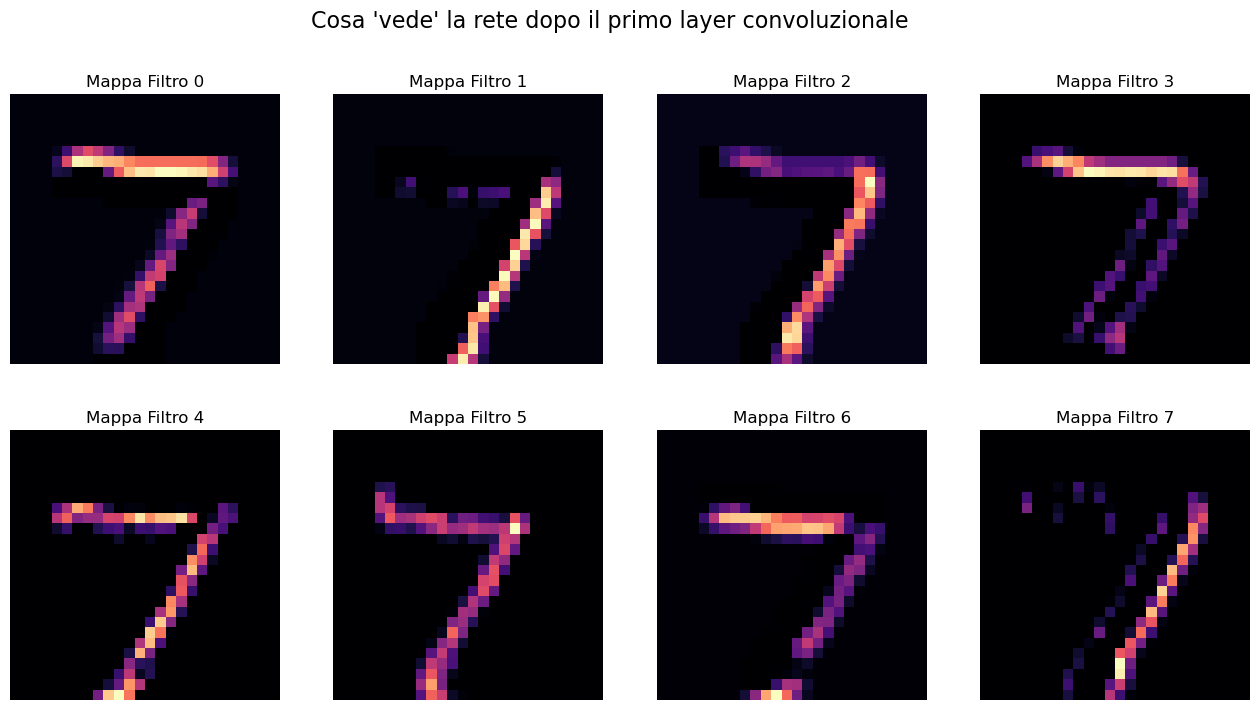

1

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPARAZIONE DATI ---
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalizzazione e Reshape (N, 28, 28, 1)
train_images = train_images.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

# --- 2. ARCHITETTURA CON API FUNZIONALE ---
def build_model():
    inputs = Input(shape=(28, 28, 1), name="Input_Layer")
    
    # Primo blocco: 32 filtri 3x3
    # Calcolo: ((3*3*1)+1)*32 = 320 parametri
    x = layers.Conv2D(32, (3, 3), activation='relu', name='Conv1')(inputs)
    x = layers.MaxPooling2D((2, 2), name='Pool1')(x)
    
    # Secondo blocco: 64 filtri 3x3
    # Calcolo: ((3*3*32)+1)*64 = 18.496 parametri
    x = layers.Conv2D(64, (3, 3), activation='relu', name='Conv2')(x)
    x = layers.MaxPooling2D((2, 2), name='Pool2')(x)
    
    # Testa del modello
    x = layers.Flatten()(x) #permette di convertire le matrici in arrays monodimensionali
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="MNIST_Functional_2025")

model = build_model()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training
model.fit(train_images, train_labels, epochs=3, batch_size=64)

# --- 3. ESTRAZIONE DELLE ATTIVAZIONI (Feature Maps) ---

# Prendiamo un'immagine di esempio, # numero 7
img = test_images[0:1] 

# Creiamo il modello di visualizzazione usando i puntatori definiti nel grafo
# Ora model.input è garantito esistere perché il modello è Funzionale
activation_model = models.Model(inputs=model.input, 
                                outputs=model.get_layer('Conv1').output)

# Otteniamo le mappe (forma: 1, 26, 26, 32)
activations = activation_model.predict(img, verbose=0)

# --- 4. VISUALIZZAZIONE ---
plt.figure(figsize=(16, 8))
for i in range(8): # Visualizziamo i primi 8 canali
    plt.subplot(2, 4, i+1)
    plt.imshow(activations[0, :, :, i], cmap='magma')
    plt.axis('off')
    plt.title(f"Mappa Filtro {i}")

plt.suptitle("Cosa 'vede' la rete dopo il primo layer convoluzionale", fontsize=16)
plt.show()
1

Il reshape a 4 dimensioni è il passaporto indispensabile per entrare nel mondo della CNN, per nutrire layer convoluzonali mantenendo la coerenza spaziale dei dati.
Lo stacking di Conv2D e MaxPooling2D per l'estrazione automatica e la sintesi delle caratteristiche visive.
L'ispezione dei filtri appresi ci permete di validare l'apprendimento gerarchico e la qualità della specializzazione della rete.